## Task 1 EDA and Data Cleaning

### 1. Imports and data loading

In [22]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42 #To control randomness

### 1.1 Load and Inspect raw data

In [23]:
raw_df = pd.read_csv('Cars.csv')

print(f"Shape: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns")
raw_df.head()


Shape: 8128 rows, 13 columns


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [24]:
# Data types and non-null counts 
raw_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [25]:
# Quick statistical summary of the numeric columns
raw_df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
year,8128.0,2013.804011,4.044249,1983.0,2011.0,2015.0,2017.0,2020.0
selling_price,8128.0,638271.807702,806253.403508,29999.0,254999.0,450000.0,675000.0,10000000.0
km_driven,8128.0,69819.510827,56550.554958,1.0,35000.0,60000.0,98000.0,2360457.0
seats,7907.0,5.416719,0.959588,2.0,5.0,5.0,5.0,14.0


## 2. Initial Exploratory Data Analysis (EDA) before preprocessing or cleaning of any kind
- how much data is missing and where,
- the shape of the target variable and whether it needs transforming,
- how categorical features are distributed,
- how numeric features relate to price.




### 2.1 Missing Values

In [26]:
# Count and percentage of missing values per column
missing = raw_df.isnull().sum()
missing_pct = (missing / len(raw_df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_summary


,missing_count,missing_pct
torque,222,2.73
mileage,221,2.72
engine,221,2.72
seats,221,2.72
max_power,215,2.65


Because only a small percentage of whole feature is missing, I would not drop the whole row and instead apply imputation techniques in the following steps. 

### 2.2 Target variable (Selling price)

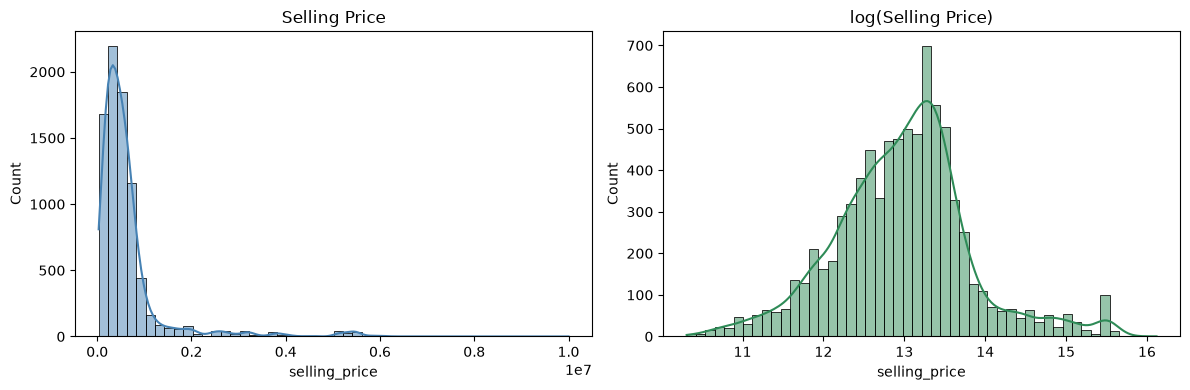

Raw selling_price skewness:      4.19
log(selling_price) skewness:     0.22


In [27]:

#Seeing the distribution of the target feature 
# Comparing raw distribution and log transformed distribution 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(raw_df['selling_price'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Selling Price')

sns.histplot(np.log(raw_df['selling_price']), bins=50, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('log(Selling Price)')

plt.tight_layout()
plt.show()

print(f"Raw selling_price skewness:      {raw_df['selling_price'].skew():.2f}")
print(f"log(selling_price) skewness:     {np.log(raw_df['selling_price']).skew():.2f}")


#### The raw target is heavily right-skewed (a small number of very expensive cars), which is where log transform helps. We can see from the right image that log transformation scaled the data to a normal looking distribution

### 2.3 Categorical Features

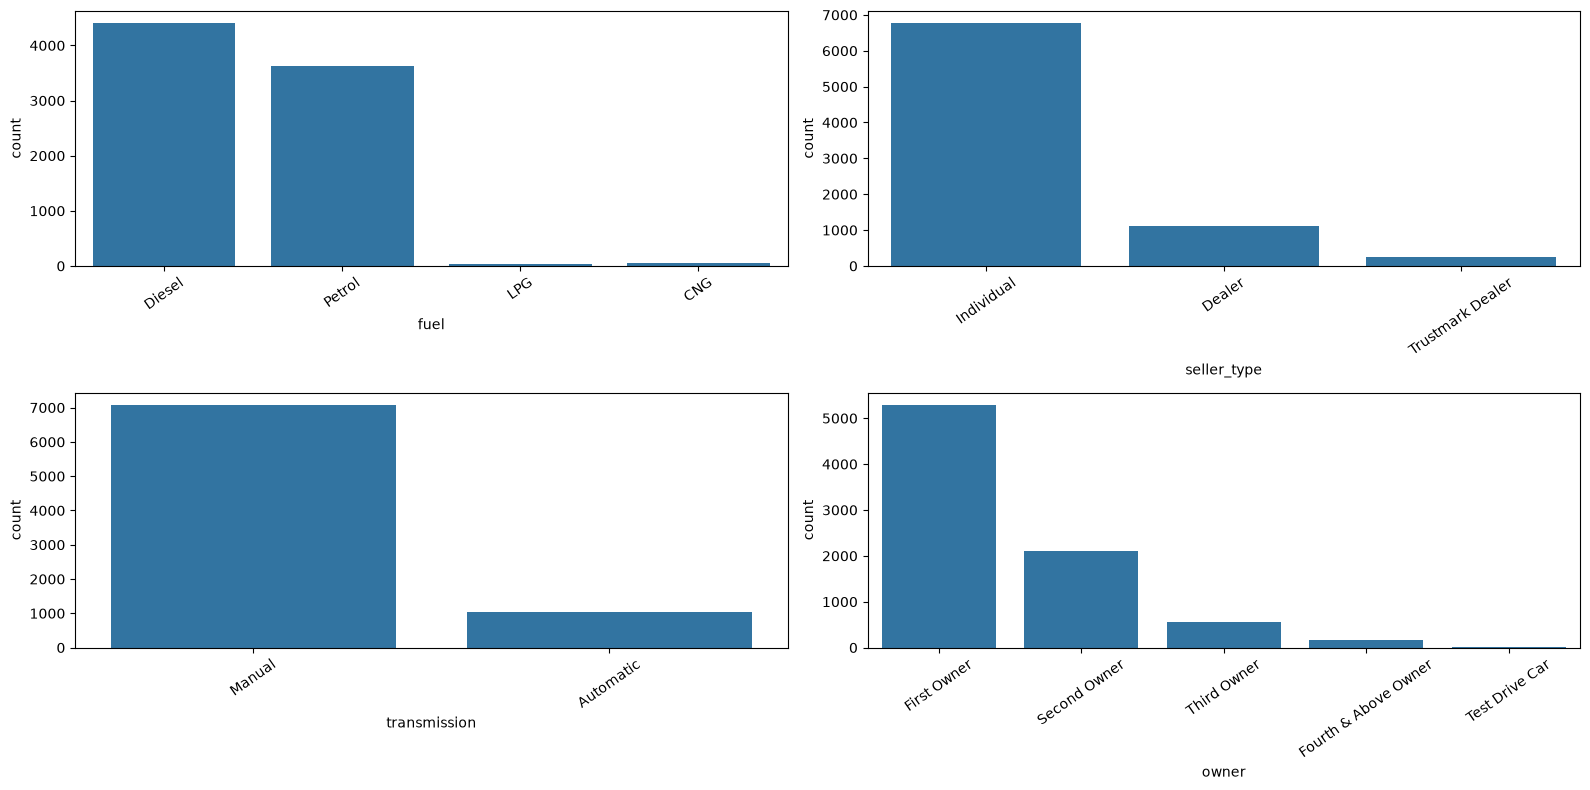

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

sns.countplot(data=raw_df, x="fuel", ax=axes[0])
sns.countplot(data=raw_df, x="seller_type", ax=axes[1])
sns.countplot(data=raw_df, x="transmission", ax=axes[2])
sns.countplot(data=raw_df, x="owner", ax=axes[3])

for ax in axes:
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

`fuel` is mostly Diesel and Petrol, with CNG and LPG making up a tiny fraction of listings and using a different mileage unit, km/kg. It can cause misleading patterns so we will drop the rows consisting these two values. 
`owner` is dominated by first-owner cars, and only 5 listings are "Test Drive Car", confirming they
are rare outliers and not a meaningful category to model. We will drop rows with this value as well.

### 2.4 Numeric features vs. price

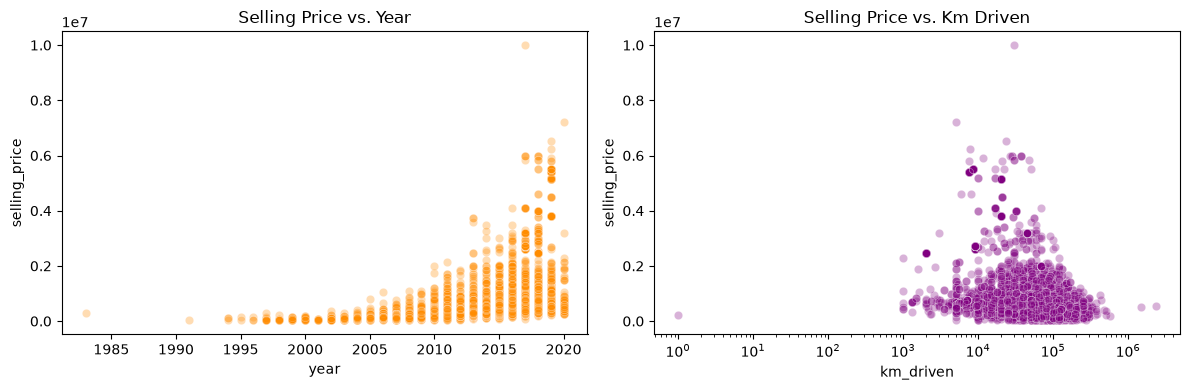

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(data=raw_df, x='year', y='selling_price', alpha=0.3, ax=axes[0], color='darkorange')
axes[0].set_title('Selling Price vs. Year')

sns.scatterplot(data=raw_df, x='km_driven', y='selling_price', alpha=0.3, ax=axes[1], color='purple')
axes[1].set_title('Selling Price vs. Km Driven')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()


Newer cars command higher prices, and price falls off with `km_driven`. Diesel and automatic-transmission cars tend to sell for more (lower plots), likely because they overlap with larger, newer, higher-spec vehicles.

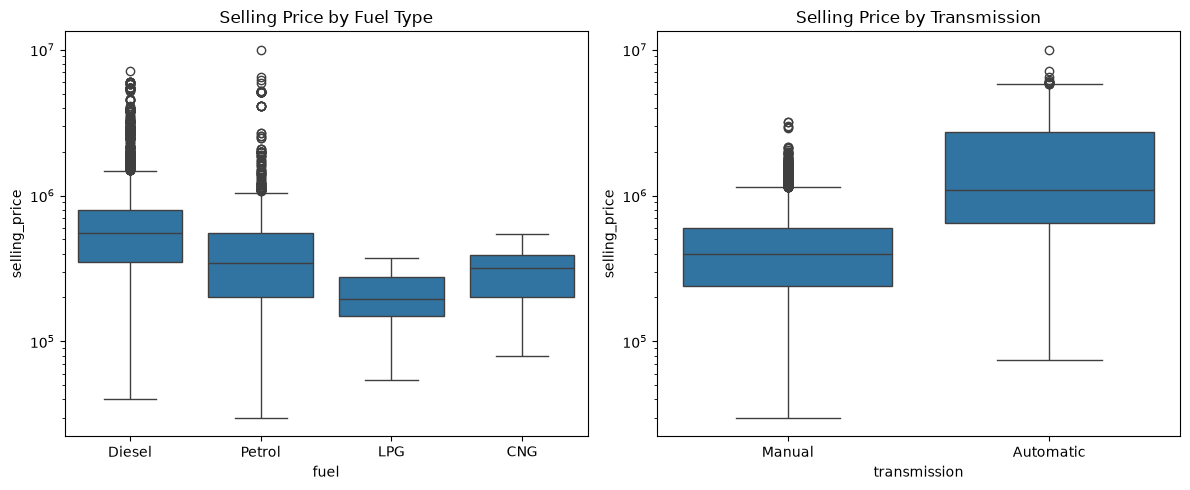

In [30]:
# Selling price by fuel type and by transmission
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=raw_df, x='fuel', y='selling_price', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Selling Price by Fuel Type')

sns.boxplot(data=raw_df, x='transmission', y='selling_price', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Selling Price by Transmission')

plt.tight_layout()
plt.show()


### 2.5 Brand Overview

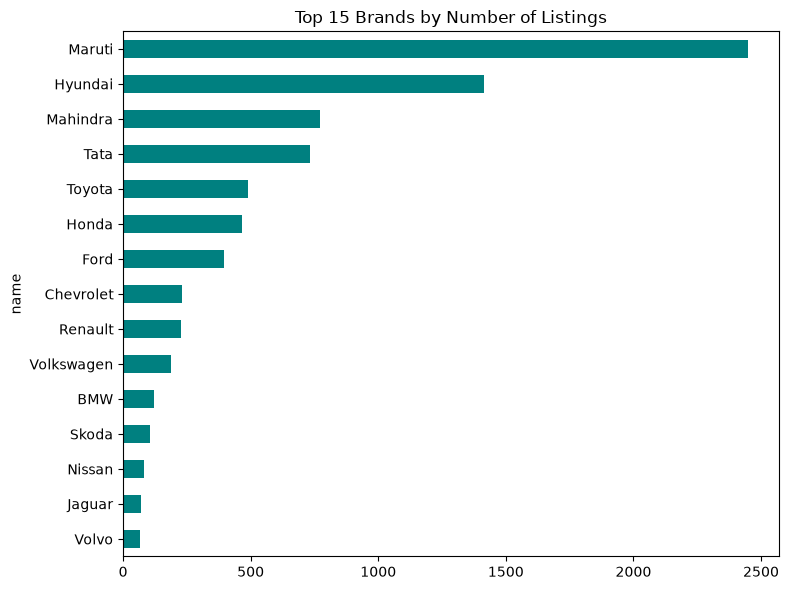

In [31]:
# Keeping only the first word from the 'name' column as that is the brand
brand_preview = raw_df['name'].apply(lambda x: x.split()[0])
fig, ax = plt.subplots(figsize=(8, 6))
brand_preview.value_counts().head(15).plot(kind='barh', ax=ax, color='teal')
ax.invert_yaxis()
ax.set_title('Top 15 Brands by Number of Listings')
plt.tight_layout()
plt.show()


## 3. Data Preprocessing
Now we will preprocess the data, making it suitable for the model to learn. Just to be safe, a copy of the dataframe is made where the preprocessing is done, so if we want to go back, we can.

In [34]:
df = raw_df.copy()
print(f"Starting shape: {df.shape}")


Starting shape: (8128, 13)


#### 3.1 Keeping only the first word of `name` column as that is the manufacturer/brand and drop the rest of the string, which is our new column `brand`. then dropping the `name` column entirely. 

In [35]:

df['brand'] = df['name'].apply(lambda x: x.split()[0])
df = df.drop(columns=['name'])
df[['brand']].head()

,brand
0,Maruti
1,Skoda
2,Honda
3,Hyundai
4,Maruti


#### 3.2 Encoding `owner` as an ordinal number as it clearly has an hierechical impact on selling price



In [36]:
owner_map = {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 5,
}
df['owner'] = df['owner'].map(owner_map)
df['owner'].value_counts().sort_index()


owner
1    5289
2    2105
3     555
4     174
5       5
Name: count, dtype: int64

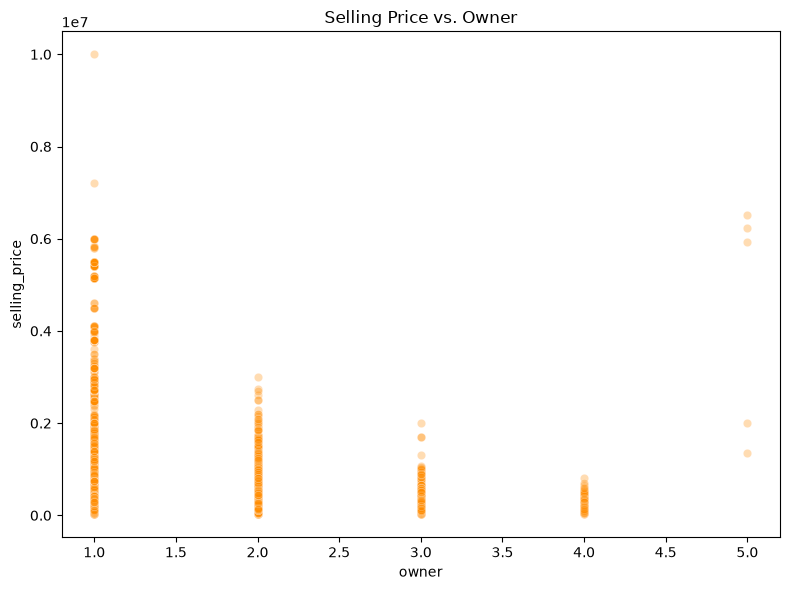

In [37]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df, x='owner', y='selling_price', alpha=0.3, color='darkorange')
ax.set_title('Selling Price vs. Owner')
plt.tight_layout()
plt.show()



#### 3.3 Removing Test Drive Cars (Owner == 5) as they are essentially demo vehicles sold by dealerships at unrealistically high prices. 



In [38]:
n_before = len(df)
df = df[df['owner'] != 5].reset_index(drop=True)
print(f"Removed {n_before - len(df)} Test Drive Car rows -> new shape: {df.shape}")

Removed 5 Test Drive Car rows -> new shape: (8123, 13)


#### 3.4 Dropping CNG and LPG rows from `fuel` column as they have different mileage unit

In [39]:
n_before = len(df)
df = df[~df['fuel'].isin(['CNG', 'LPG'])].reset_index(drop=True)
print(f"Removed {n_before - len(df)} CNG/LPG rows -> new shape: {df.shape}")
df['fuel'].value_counts()


Removed 95 CNG/LPG rows -> new shape: (8028, 13)


fuel
Diesel    4401
Petrol    3627
Name: count, dtype: int64

#### 3.5 Stripping "kmpl" from the `mileage` column entries and converting them to floats

In [40]:
def parse_mileage(value):
    """Convert a string like '23.4 kmpl' to the float 23.4."""
    if pd.isna(value):
        return np.nan
    number_part = value.str.split(' ')[0] if hasattr(value, 'str') else value.split(' ')[0]
    return float(number_part)

df['mileage'] = df['mileage'].apply(parse_mileage)
df[['mileage']].describe().T


,count,mean,std,min,25%,50%,75%,max
mileage,7814.0,19.391962,4.001972,0.0,16.78,19.3,22.32,42.0


#### 3.6 Stripping "CC" from the `engine` column entries and converting them to floats

In [41]:
def parse_engine(value):
    """Convert a string like '1248 CC' to the float 1248.0."""
    if pd.isna(value):
        return np.nan
    return float(value.replace('CC', '').strip())

df['engine'] = df['engine'].apply(parse_engine)
df[['engine']].describe().T


,count,mean,std,min,25%,50%,75%,max
engine,7814.0,1462.91464,504.759742,624.0,1197.0,1248.0,1582.0,3604.0


#### 3.7 Stripping "bhp" from the `max_power` column entries and converting them to floats

In [42]:
def parse_power(value):
    """Convert a string like '74 bhp' to the float 74.0. A few rows have an empty
    number before 'bhp'. for now, those become NaN and are handled by imputation later."""
    if pd.isna(value):
        return np.nan
    cleaned = value.replace('bhp', '').strip()
    return float(cleaned) if cleaned != '' else np.nan

df['max_power'] = df['max_power'].apply(parse_power)
df[['max_power']].describe().T


,count,mean,std,min,25%,50%,75%,max
max_power,7820.0,91.819726,35.804513,0.0,68.85,82.4,102.0,400.0


### 3.8 Treat implausible zero values in `mileage` and `max_power` as missing

Beyond the values that were genuinely blank in the raw data, a closer look at `mileage`
and `max_power` turns up entries of exactly **0**. A car cannot get 0 kmpl
fuel efficiency or produce 0 bhp of power and still be a used car for sale. these are not real measurements. If we leave these as literal zeros, the model would treat "this car gets 0 km per liter", which would be misleading for the model. Instead, we
convert these zeros to `NaN` so they flow through the *same* median imputation step as any
other missing value later in the notebook.

In [43]:
n_zero_mileage = (df['mileage'] == 0).sum()
n_zero_power = (df['max_power'] == 0).sum()
print(f"mileage == 0:   {n_zero_mileage} rows ")
print(f"max_power == 0: {n_zero_power} rows")

df.loc[df['mileage'] == 0, 'mileage'] = np.nan
df.loc[df['max_power'] == 0, 'max_power'] = np.nan


mileage == 0:   17 rows 
max_power == 0: 6 rows


### 3.9 Remove implausible `km_driven` outliers

From the EDA plot before of selling price Vs km driven, I noticed two outliers. So, plotting the median of the column and 5 highest numbers, I can see that the first two values are too high to be realistic. The two largest `km_driven` values in the dataset are **2,360,457 km** (a 13-year-old
Hyundai) and **1,500,000 km** (an 8-year-old Mahindra) and the median is 60000 km. Their driven kilometers/number of year after manufacturing is not realistic either. Also, the third-highest
`km_driven` value in the entire dataset (577,414 km) is not even half of the first two values.
Hence, I will remove only these two specific, extreme rows.

In [52]:
print(f" Median {df['km_driven'].median()}")
print(df['km_driven'].sort_values(ascending=False).head(5).to_string())


 Median 60000.0
3445    2360457
1798    1500000
3466     577414
6585     500000
3599     500000


In [53]:
highest_two_indices = df["km_driven"].nlargest(2).index
df = df.drop(index=highest_two_indices)

In [54]:
df = df.reset_index(drop=True)

In [55]:
print(f" Median {df['km_driven'].median()}")
print(df['km_driven'].sort_values(ascending=False).head(5).to_string())


 Median 60000.0
3464    577414
6583    500000
3597    500000
5043    475000
5124    440000


#### 3.10 Dropping `torque` as per assignment requirement

In [44]:
df = df.drop(columns=['torque'])


In [56]:
#Final Preprocessed Data
column_order = ['brand', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
                 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats']
df = df[column_order]
print(df.shape)
df.head()


(8026, 12)


,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0


### 3.11 Remove exact duplicate rows

Dropping the duplicate rows to prevent data leakage

In [58]:
n_before = len(df)
n_duplicates = df.duplicated().sum()
print(f"Found {n_duplicates} exact duplicate rows ({n_duplicates / len(df) * 100:.1f}% of the cleaned data)")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed duplicates: {n_before} -> {len(df)} rows")


Found 1220 exact duplicate rows (15.2% of the cleaned data)
Removed duplicates: 8026 -> 6806 rows


In [59]:
print(f"Cleaned shape: {df.shape}")
df.isnull().sum()

Cleaned shape: (6806, 12)


brand              0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          216
engine           201
max_power        201
seats            201
dtype: int64

#### The data has missing values, but I will split it into train/test first and then handle the missing values. This way, no information from the test set leaks into training. and also apply log transformation to the target column

### EDA after cleaning

The following views help reveal monotonic relationships, outliers, and brand-level price differences. Correlation describes linear association only; it does not prove causation.


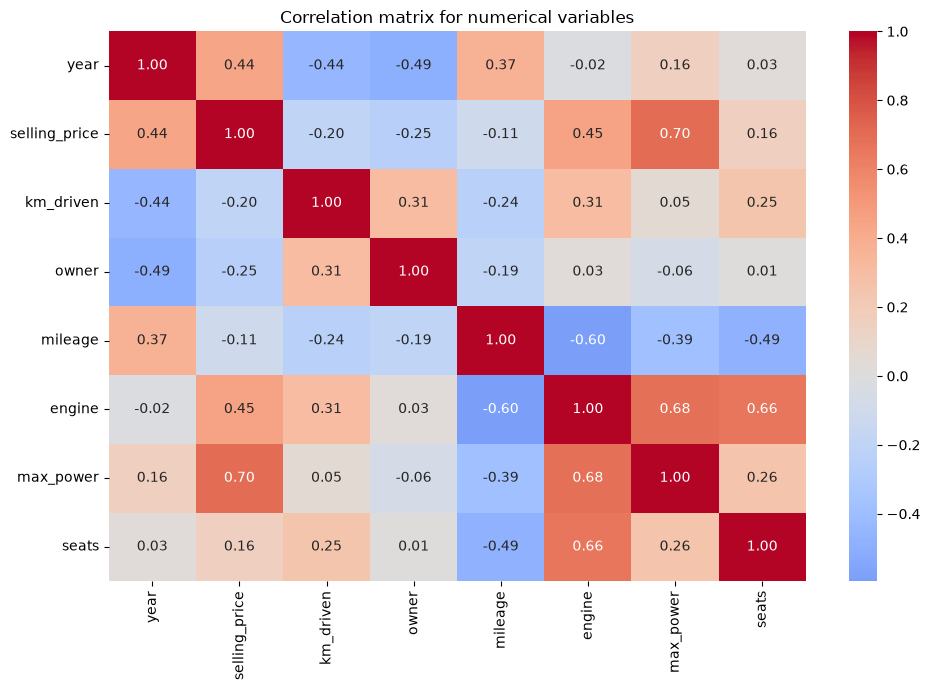

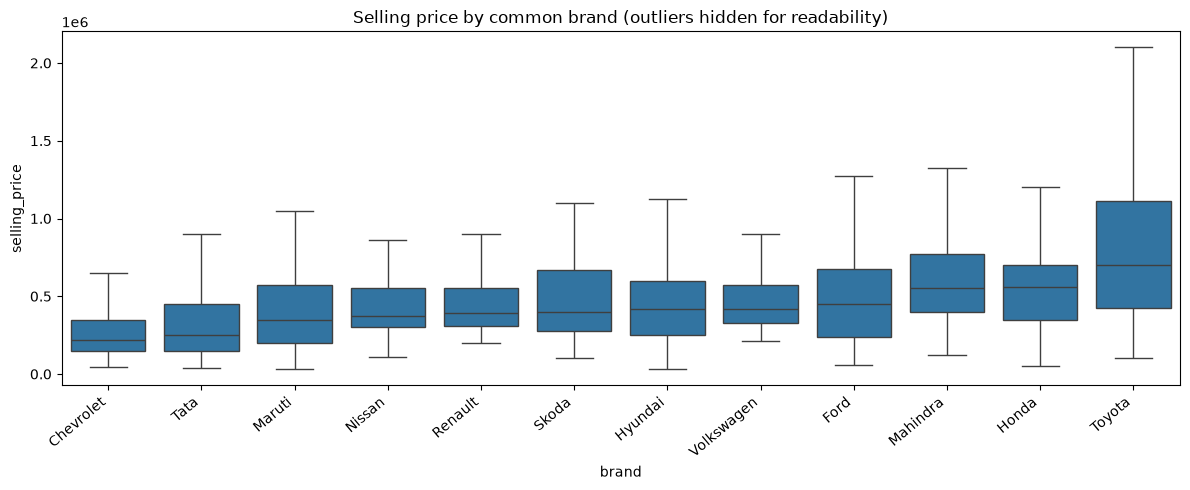

In [60]:
numeric_cols = ['year', 'selling_price', 'km_driven', 'owner', 'mileage', 'engine', 'max_power', 'seats']
plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix for numerical variables')
plt.tight_layout()
plt.show()

top_brands = df['brand'].value_counts().head(12).index
brand_order = (df[df['brand'].isin(top_brands)]
               .groupby('brand')['selling_price'].median()
               .sort_values().index)
plt.figure(figsize=(12, 5))
sns.boxplot(data=df[df['brand'].isin(top_brands)], x='brand', y='selling_price', order=brand_order, showfliers=False)
plt.xticks(rotation=40, ha='right')
plt.title('Selling price by common brand (outliers hidden for readability)')
plt.tight_layout()
plt.show()


## Task2: Model Training, Evaluation, Inference and Report

### 4. Train/test Split and Missing value imputation

In [61]:
X = df.drop(columns=['selling_price'])
y = np.log(df['selling_price'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train size: {X_train.shape[0]}   Test size: {X_test.shape[0]}")


Train size: 5444   Test size: 1362


In [62]:
# Missing values are concentrated in a handful of numeric columns. Median imputation is 
# the choice here since these features (engine size, mileage,
# max power) are right-skewed and medians are less sensitive to outliers than means.
X_train.isnull().sum()[X_train.isnull().sum() > 0]


mileage      171
engine       156
max_power    156
seats        156
dtype: int64

### 5. Feature Encoding and Scaling
The `ColumnTransformer` that handles numeric features' missing values with median-imputation and then standardizes the data. Again, it applies 'most frequest' imputation to categorical features and the one hot encodes it. 
Wrapping this in a `Pipeline`/`ColumnTransformer` means the exact same fitted transformation
(fitted only on the training data) is applied consistently to the test set and, later, to new
user input in the web app.

In [63]:
numeric_features = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'owner']
categorical_features = ['brand', 'fuel', 'seller_type', 'transmission']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])




In [64]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

### 6.Model Selection
We will now compare a spread of regressors covering different families, including:

- **Linear Regression** 
- **Ridge** / **Lasso** 
- **Decision Tree** 
- **Random Forest**
- **Gradient Boosting** 

Each candidate is wrapped in the same preprocessing pipeline and evaluated with **5-fold
cross-validation on the training set only** (the test set is held out untouched until the very
end). We track both R² and RMSE (on the log-price scale).

In [65]:
candidate_models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Lasso': Lasso(alpha=0.001, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=15, n_jobs=-1, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
}

cv_results = []
for name, model in candidate_models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    scores = cross_validate(
        pipe, X_train, y_train, cv=5,
        scoring=('r2', 'neg_root_mean_squared_error'),
        n_jobs=-1
    )
    cv_results.append({
        'Model': name,
        'CV R2 (mean)': scores['test_r2'].mean(),
        'CV R2 (std)': scores['test_r2'].std(),
        'CV RMSE (mean, log-scale)': -scores['test_neg_root_mean_squared_error'].mean(),
    })

cv_results_df = pd.DataFrame(cv_results).sort_values('CV R2 (mean)', ascending=False).reset_index(drop=True)
cv_results_df


,Model,CV R2 (mean),CV R2 (std),"CV RMSE (mean, log-scale)"
0,Random Forest,0.906223,0.004271,0.232444
1,Gradient Boosting,0.904540,0.006366,0.234416
2,Ridge,0.880113,0.009943,0.262623
3,Linear Regression,0.879864,0.009990,0.262900
4,Lasso,0.877320,0.009908,0.265674
5,Decision Tree,0.871554,0.008206,0.271949


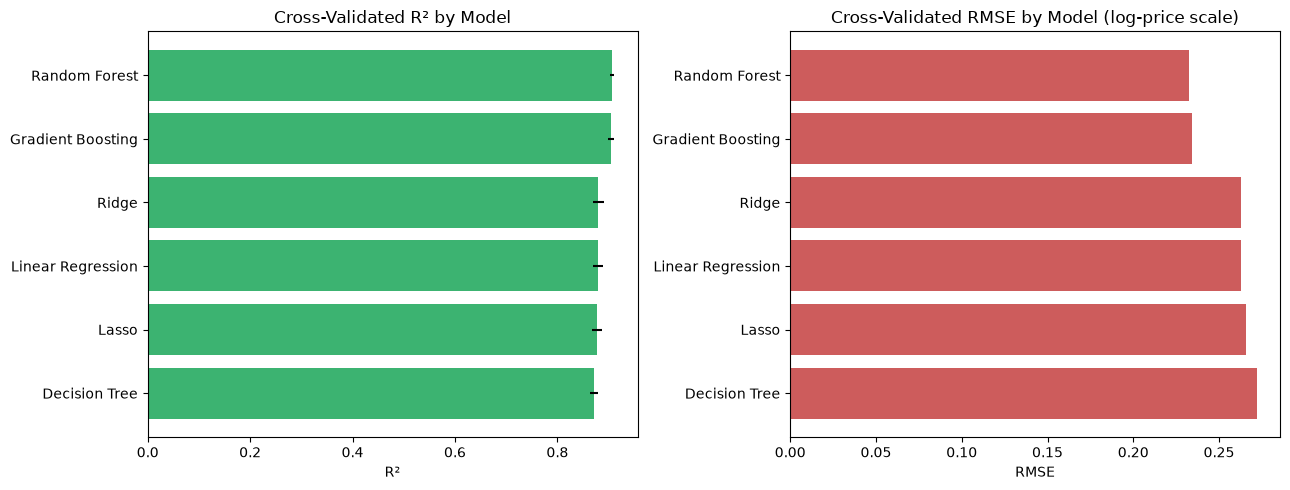

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = cv_results_df.sort_values('CV R2 (mean)')['Model']
axes[0].barh(cv_results_df.sort_values('CV R2 (mean)')['Model'],
             cv_results_df.sort_values('CV R2 (mean)')['CV R2 (mean)'],
             xerr=cv_results_df.sort_values('CV R2 (mean)')['CV R2 (std)'], color='mediumseagreen')
axes[0].set_title('Cross-Validated R² by Model')
axes[0].set_xlabel('R²')

axes[1].barh(cv_results_df.sort_values('CV RMSE (mean, log-scale)', ascending=False)['Model'],
             cv_results_df.sort_values('CV RMSE (mean, log-scale)', ascending=False)['CV RMSE (mean, log-scale)'],
             color='indianred')
axes[1].set_title('Cross-Validated RMSE by Model (log-price scale)')
axes[1].set_xlabel('RMSE')

plt.tight_layout()
plt.show()


**Random Forest** and **Gradient Boosting** clearly outperform the linear models and the single
Decision Tree on cross-validated R². This makes sense: car pricing involves non-linear effects and
interactions, such as, the effect of `km_driven` on price likely depends on `year`, and different brands
have very different price levels for the same specs, that tree-based ensembles can capture but a
plain linear model cannot. Random Forest edges out Gradient Boosting slightly and has lower variance
across folds, so we select **Random Forest** as our final model.

## 7. Final Model Training and Test Set Evaluation

We now retrain our trained Random Forest model on the **entire training set** and evaluate it
**once** on the held-out test set. Predictions are made on the log scale and then transformed back
with `np.exp` to compare against the original selling price/

In [67]:
best_model_name = cv_results_df.iloc[0]['Model']
print(f"Selected model: {best_model_name}")
    
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, max_depth=15, n_jobs=-1, random_state=RANDOM_STATE)),
])

final_pipeline.fit(X_train, y_train)


Selected model: Random Forest


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [76]:
# Predict on the log scale, then transform back to the original price scale for evaluation
pred_y_log = final_pipeline.predict(X_test)
pred_y = np.exp(pred_y_log)
true_y = np.exp(y_test)

mae = mean_absolute_error(true_y, pred_y)
rmse = np.sqrt(mean_squared_error(true_y, pred_y))
r2 = r2_score(true_y, pred_y)
r2_log = r2_score(y_test, pred_y_log)

print("Test set performance (original  price scale):")
print(f"  MAE  = {mae:,.0f}")
print(f"  RMSE = {rmse:,.0f}")
print(f"  R2   = {r2:.4f}")
print()
print(f"Test set R2 on log-price scale: {r2_log:.4f}")


Test set performance (original  price scale):
  MAE  = 74,574
  RMSE = 210,046
  R2   = 0.8440

Test set R2 on log-price scale: 0.9218


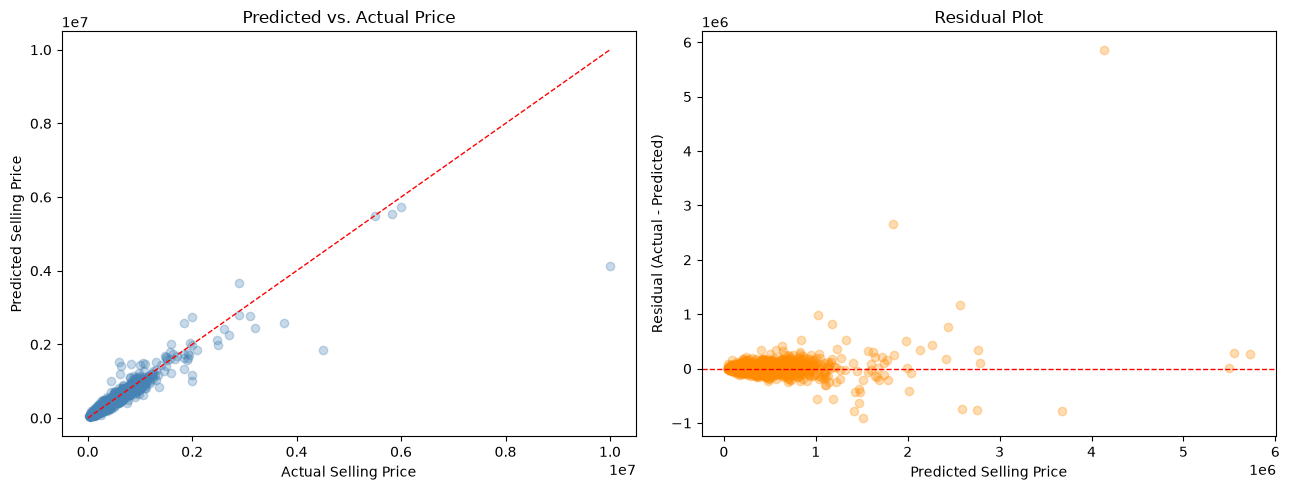

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(true_y, pred_y, alpha=0.3, color='steelblue')
lims = [0, max(true_y.max(), pred_y.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlabel('Actual Selling Price')
axes[0].set_ylabel('Predicted Selling Price')
axes[0].set_title('Predicted vs. Actual Price')

residuals = true_y - pred_y
axes[1].scatter(pred_y, residuals, alpha=0.3, color='darkorange')
axes[1].axhline(0, color='r', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted Selling Price')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()


The model tracks the diagonal closely for low-to-mid priced cars, with residuals widening for
very expensive cars. Since high-end vehicles are rarer in the training data and
their prices probably depend on brand prestige and options the dataset doesn't fully capture.

## 8. Feature Importance

We inspect which features the Random Forest relies on most and
compare against Linear Regression coefficients to see
whether both model families agree on what drives price.

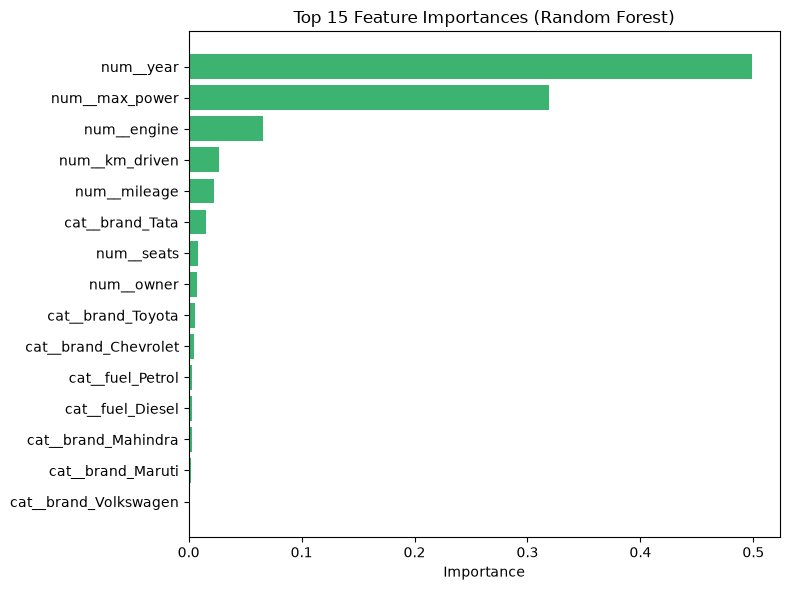

,feature,importance
0,num__year,0.498686
4,num__max_power,0.319423
3,num__engine,0.065914
1,num__km_driven,0.027282
2,num__mileage,0.022726
35,cat__brand_Tata,0.015207
5,num__seats,0.008587
6,num__owner,0.007750
36,cat__brand_Toyota,0.005655
11,cat__brand_Chevrolet,0.004319


In [70]:
feature_names = final_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = final_pipeline.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance_df['feature'][::-1], importance_df['importance'][::-1], color='mediumseagreen')
ax.set_title('Top 15 Feature Importances (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

importance_df


In [71]:
# For comparison: Linear Regression coefficients on the same preprocessed features
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', LinearRegression())])
lr_pipeline.fit(X_train, y_train)

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': lr_pipeline.named_steps['model'].coef_
})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df.sort_values('abs_coefficient', ascending=False).drop(columns='abs_coefficient').head(15)


,feature,coefficient
23,cat__brand_Land,0.631777
24,cat__brand_Lexus,0.602033
35,cat__brand_Tata,-0.533102
11,cat__brand_Chevrolet,-0.486355
0,num__year,0.449769
13,cat__brand_Datsun,-0.447624
7,cat__brand_Ambassador,0.415805
38,cat__brand_Volvo,0.392684
8,cat__brand_Ashok,-0.345004
28,cat__brand_Mercedes-Benz,0.332348


### 9. Saving the Final Model

In [72]:
import os
import joblib
os.makedirs('model', exist_ok=True)
joblib.dump(final_pipeline, 'model/car_price_model.pkl')
print("Saved pipeline to model/car_price_model.pkl")


Saved pipeline to model/car_price_model.pkl


### 10. Inference using dummy inputs and a case where an input is skipped

In [74]:

loaded_pipeline = joblib.load('model/car_price_model.pkl')

In [ ]:
# The model works if all features are given. Even if some are not given, those features are assumed from the imputation method applied during training.
new_cars = pd.DataFrame([
    {
        # A fully-specified listing
        'brand': 'Maruti',
        'year': 2019,
        'km_driven': 35000,
        'fuel': 'Petrol',
        'seller_type': 'Individual',
        'transmission': 'Manual',
        'owner': 1,
        'mileage': 21.5,
        'engine': 1197,
        'max_power': 82,
        'seats': 5,
    },
    {
        # A listing where the user skipped mileage / engine / seats
        # left as NaN, exactly like an unanswered form field.
        'brand': 'Hyundai',
        'year': 2015,
        'km_driven': 80000,
        'fuel': 'Diesel',
        'seller_type': 'Dealer',
        'transmission': 'Manual',
        'owner': 2,
        'mileage': np.nan,
        'engine': np.nan,
        'max_power': 88.5,
        'seats': np.nan,
    },
])

# Predict on the log scale, then transform back to actual price with np.exp
pred_log_price = loaded_pipeline.predict(new_cars)
pred_price = np.exp(pred_log_price)

results = new_cars.copy()
results['predicted_selling_price'] = pred_price.round(0)
results


,brand,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,predicted_selling_price
0,Maruti,2019,35000,Petrol,Individual,Manual,1,21.5,1197.0,82.0,5.0,610398.0
1,Hyundai,2015,80000,Diesel,Dealer,Manual,2,NaN,NaN,88.5,NaN,542994.0


## Task 2: Report



#### Which features matter, and why
The Random Forest's impurity-based importances show that
**`year`** (≈50% of total importance) and **`max_power`** (≈32%) dominate the prediction,
accounting for the vast majority of the model's explanatory power. This information matches with intuition. `year`
is a strong proxy for a car's overall condition, technology, and remaining useful life, while
`max_power` is a strong proxy for performance tier of the car, which is one of the
biggest drivers of price in any car market. `engine` , `km_driven` , and `mileage` 
contribute noticeably less on their own, most probably because they are correlated with `max_power` and
`year` respectively. This is why the tree ensemble doesn't need to lean on them as heavily once the two
dominant features are used. `brand` matters, but its effect is spread thinly across many one-hot
columns. `Tata` is the single most important brand indicator (≈1.5%), followed by `Toyota` and
`Chevrolet`, with `seats` and `owner` contributing the least of the numeric features. Interestingly,
the Linear Regression coefficients tell a different story. Luxury or rare brands like
Land Rover, Lexus, Mercedes-Benz, BMW have some of the largest *positive* coefficients and
budget/commercial brands like Tata and Chevrolet the largest *negative* ones. My analysis is that because a *linear*
model needs a large brand-specific offset to capture the premium (or discount) those cars command,
whereas a tree-based model can instead just split on `max_power`/`engine` and implicitly recover much
of that same signal, spreading credit away from any single brand indicator.

#### Which algorithms perform well, and why
Across 5-fold cross-validation, the tree ensembles beat the linear family.
**Random Forest** achieved the best CV R² (≈0.906), only narrowly ahead of **Gradient Boosting**
(≈0.905), while **Linear Regression**, **Ridge**, and **Lasso** all clustered around R² ≈ 0.88, and
the single **Decision Tree** landed a bit lower at R² ≈ 0.87. On
the held-out test set, the final Random Forest model reached an R² of ≈0.84 on the original price
scale (≈0.92 on the log-price scale it was actually trained on) with a mean absolute error of about
74,600 in price. The noticeably lower R² on the original price scale versus the log scale is important to notice because predictions are made in log-space and then converted back with `np.exp`.  A small or acceptable
log-scale error on an expensive car translates into a large absolute error once transformed
back, so R² computed on raw prices is more sensitive to the handful of very expensive cars in the
test set than R² computed on log-prices. Ensembles of trees still outperform plain linear models here
because car pricing is driven by non-linear effects and interactions. It means that the price penalty per
additional 10,000 km driven is not the same for a 3-year-old car as for a 15-year-old car, and the
"value" of extra engine power differs by brand and segment. A linear model can only capture such
interactions if they are manually engineered as extra features, whereas a tree can split on different
features at different depths and discover these interactions automatically. Random Forest also had
the lowest variance across CV folds, which is why we kept it as the final model even though its
advantage over Gradient Boosting is little. Regularized linear models (Ridge/Lasso) performed
almost identically to plain Linear Regression, implying that overfitting was not a major issue for the
linear family here. Their ceiling is simply lower because the true relationship between features and
price is non-linear.

So the main takeaway from this is that the two questions that matter most when
a user fills in the form are *"how old is the car?"* and *"how powerful is the engine?"*. The model
should be most sensitive to these two inputs, while fields like seat count or ownership history matter comparatively less. 
